## Import

In [1]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

import optuna
from sklearn.model_selection import GridSearchCV 

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, max_error

import pandas as pd

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from ML.utils.Model_trainer import Model_trainer
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A/fine_tuned_models/"
path_to_predictions = pre_path + "predictions/model_A/fine_tuned_models/"
tag = "Base"
output_parameters = ["mass", "radius"]

In [4]:
# def grid_search(scoring, cv_params, cv, verbose, n_jobs, refit, **kwargs):
#     gscv = GridSearchCV(XGBRegressor(**kwargs),
#                         param_grid = cv_params,
#                         scoring = scoring,
#                         cv = cv,
#                         verbose = verbose,
#                         n_jobs = n_jobs,
#                         refit=refit
#     )

#     gscv.fit(X_train,y_train)
#     return gscv

def display_grid_search(gscv):
    df = pd.DataFrame.from_dict(gscv.cv_results_)
    pd.set_option('display.max_columns', None)
    display(df)
    print(f"Best parameters {gscv.best_params_}")
    print(f"Best score {gscv.best_score_}")

# Faire le fine-tuning avec Base et random_forest, KNN, decision tree

## Data preparation

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading MIST dataframe from csv file...


In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3, 4, 5]})

In [7]:
X_train, X_test, y_train, y_test = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], random_state=12, print_stats=True)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 298.5447575808816
Median value in train data for the star_mass parameter: 2.0816081316727946
Mean value in train data for the star_mass parameter: 7.558407372495925

Range in train data for the log_R parameter : -0.9974747647513328 - 3.129269620812593
Median value in train data for the log_R parameter: 1.4993114860984695
Mean value in train data for the log_R parameter: 1.3944707591667809

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981896729906 - 296.5221171165397
Median value in test data for the star_mass parameter: 2.082595606409119
Mean value in test data for the star_mass parameter: 7.471864103970097

Range in test data for the log_R parameter : -0.9974234436680278 - 3.1297545143214007
Median value in test data for the log_R parameter: 1.5026448988619927
Mean value in test data for the log_R parameter: 1.396340263115711



## Fine-tuning

### Decision tree

#### Tuning the criterion parameter

In [22]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'criterion' : ["squared_error", "friedman_mse", "absolute_error", "poisson"]
            }

gscv_dt_1 = GridSearchCV(DecisionTreeRegressor(),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_dt_1.fit(X_train,y_train)
display_grid_search(gscv_dt_1)

Fitting 10 folds for each of 4 candidates, totalling 40 fits


KeyboardInterrupt: 

In [ ]:

# TODO tester les différents critère individuellement pour voir lequel prend super longtemps

### XGBoost

#### Tuning the booster and n_estimators parameters

In [ ]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'booster': ["gbtree", "dart"],
             'n_estimators': [100, 150, 200, 250, 300]
            }

gscv_xgb_1 = GridSearchCV(XGBRegressor(),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_1.fit(X_train,y_train)
display_grid_search(gscv_xgb_1)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
{'mean_fit_time': array([  20.69389312,   29.18247805,   38.35277479,   47.2308882 ,
         60.62191837,  356.08439801,  895.44667237, 1507.51369855,
       2402.25628304, 3366.69091668]), 'std_fit_time': array([0.07769418, 0.06070511, 0.13790512, 0.22198645, 0.30830806,
       0.85301046, 0.74887913, 1.29224332, 1.59952764, 1.82418495]), 'mean_score_time': array([0.26689737, 0.39263556, 0.5014365 , 0.6506825 , 0.76257923,
       1.46083403, 2.28069382, 2.9225358 , 3.89363177, 4.24273353]), 'std_score_time': array([0.0108491 , 0.01546095, 0.03380829, 0.0486309 , 0.03812669,
       0.01652387, 0.05503893, 0.04087245, 0.02967931, 0.33853908]), 'param_booster': masked_array(data=['gbtree', 'gbtree', 'gbtree', 'gbtree', 'gbtree',
                   'dart', 'dart', 'dart', 'dart', 'dart'],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value=np.str_('?')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_booster,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,...,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,20.693893,0.077694,0.266897,0.010849,gbtree,100,"{'booster': 'gbtree', 'n_estimators': 100}",-0.862622,-0.815595,-0.833992,...,-0.210185,-0.206682,-0.205544,-0.212830,-0.211501,-0.215420,-0.205422,-0.208992,0.003579,9
1,29.182478,0.060705,0.392636,0.015461,gbtree,150,"{'booster': 'gbtree', 'n_estimators': 150}",-0.771157,-0.735993,-0.758892,...,-0.192054,-0.189733,-0.189802,-0.193274,-0.190086,-0.196253,-0.189847,-0.191225,0.002417,7
2,38.352775,0.137905,0.501436,0.033808,gbtree,200,"{'booster': 'gbtree', 'n_estimators': 200}",-0.721268,-0.696496,-0.721882,...,-0.178115,-0.173815,-0.177536,-0.180543,-0.177889,-0.179410,-0.177139,-0.177351,0.002094,5
3,47.230888,0.221986,0.650682,0.048631,gbtree,250,"{'booster': 'gbtree', 'n_estimators': 250}",-0.693030,-0.667542,-0.696751,...,-0.168372,-0.164750,-0.167782,-0.169838,-0.166401,-0.170032,-0.168284,-0.167540,0.002249,4
4,60.621918,0.308308,0.762579,0.038127,gbtree,300,"{'booster': 'gbtree', 'n_estimators': 300}",-0.676538,-0.652146,-0.683637,...,-0.161682,-0.156509,-0.158714,-0.162931,-0.157452,-0.158893,-0.159840,-0.159277,0.002054,1
5,356.084398,0.853010,1.460834,0.016524,dart,100,"{'booster': 'dart', 'n_estimators': 100}",-0.862622,-0.815595,-0.833992,...,-0.210185,-0.206682,-0.205544,-0.212830,-0.211501,-0.215420,-0.205422,-0.208992,0.003579,10
6,895.446672,0.748879,2.280694,0.055039,dart,150,"{'booster': 'dart', 'n_estimators': 150}",-0.771157,-0.735993,-0.758892,...,-0.192054,-0.189733,-0.189802,-0.193274,-0.190086,-0.196253,-0.189847,-0.191225,0.002417,8
7,1507.513699,1.292243,2.922536,0.040872,dart,200,"{'booster': 'dart', 'n_estimators': 200}",-0.721268,-0.696496,-0.721882,...,-0.178115,-0.173815,-0.177536,-0.180543,-0.177889,-0.179410,-0.177139,-0.177351,0.002094,6
8,2402.256283,1.599528,3.893632,0.029679,dart,250,"{'booster': 'dart', 'n_estimators': 250}",-0.693030,-0.667542,-0.696751,...,-0.168372,-0.164750,-0.167782,-0.169838,-0.166401,-0.170032,-0.168284,-0.167540,0.002249,3
9,3366.690917,1.824185,4.242734,0.338539,dart,300,"{'booster': 'dart', 'n_estimators': 300}",-0.676538,-0.652145,-0.683637,...,-0.161682,-0.156509,-0.158714,-0.162931,-0.157452,-0.158893,-0.159840,-0.159277,0.002054,2


Best parameters {'booster': 'dart', 'n_estimators': 300}
Best score -0.6922802578352828


The results are the same with gbtree and dart, but dart takes a lot longer to train. We will choose gbtree.

More estimators improves the results, we will test with more estimators to try and find the limit at which adding more estimators does not improve the results much

In [ ]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
            }

gscv_xgb_2 = GridSearchCV(XGBRegressor(),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_2.fit(X_train,y_train)
display_grid_search(gscv_xgb_2)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,23.188663,0.054305,0.309838,0.005001,100,{'n_estimators': 100},-0.862622,-0.815595,-0.833992,-0.922820,-0.806739,-0.840190,-0.906333,-0.885421,-0.863118,-0.859691,-0.859652,0.035542,10,-0.208420,-0.203369,-0.210545,-0.210185,-0.206682,-0.205544,-0.212830,-0.211501,-0.215420,-0.205422,-0.208992,0.003579,10
1,41.873128,0.081130,0.587952,0.020353,200,{'n_estimators': 200},-0.721268,-0.696496,-0.721882,-0.773427,-0.690349,-0.740011,-0.776199,-0.735422,-0.740602,-0.746947,-0.734261,0.026842,9,-0.176690,-0.173655,-0.178720,-0.178115,-0.173815,-0.177536,-0.180543,-0.177889,-0.179410,-0.177139,-0.177351,0.002094,9
2,61.729190,0.149665,0.899116,0.037464,300,{'n_estimators': 300},-0.676538,-0.652146,-0.683637,-0.732628,-0.655791,-0.701772,-0.730894,-0.683911,-0.694332,-0.711155,-0.692280,0.026276,8,-0.159807,-0.156271,-0.160673,-0.161682,-0.156509,-0.158714,-0.162931,-0.157452,-0.158893,-0.159840,-0.159277,0.002054,8
3,81.396047,0.335990,1.383533,0.231670,400,{'n_estimators': 400},-0.650200,-0.631599,-0.663830,-0.703355,-0.637217,-0.682803,-0.709816,-0.655156,-0.672806,-0.689042,-0.669583,0.025358,7,-0.145691,-0.141360,-0.149428,-0.150069,-0.145260,-0.147627,-0.151945,-0.146064,-0.146950,-0.148499,-0.147289,0.002811,7
4,104.162949,0.490535,1.824301,0.408042,500,{'n_estimators': 500},-0.639257,-0.620956,-0.652298,-0.691265,-0.627228,-0.669581,-0.697537,-0.637327,-0.656773,-0.677557,-0.656978,0.025115,6,-0.140537,-0.134796,-0.143062,-0.141697,-0.138561,-0.140390,-0.144713,-0.137443,-0.138558,-0.140161,-0.139992,0.002696,6
5,124.983232,0.643087,2.361561,0.498340,600,{'n_estimators': 600},-0.633533,-0.612262,-0.640113,-0.685095,-0.622929,-0.660232,-0.689994,-0.631423,-0.652140,-0.670570,-0.649829,0.024969,5,-0.134402,-0.128508,-0.135870,-0.134720,-0.133726,-0.133314,-0.138347,-0.132661,-0.132750,-0.133764,-0.133806,0.002384,5
6,149.172118,0.717782,2.568778,0.636161,700,{'n_estimators': 700},-0.625569,-0.607863,-0.635133,-0.678575,-0.621181,-0.656236,-0.683569,-0.623403,-0.647427,-0.666657,-0.644561,0.024702,4,-0.127931,-0.124243,-0.129584,-0.129468,-0.128005,-0.128883,-0.132949,-0.127380,-0.128463,-0.128889,-0.128580,0.002052,4
7,158.095074,0.829726,3.024416,0.688507,800,{'n_estimators': 800},-0.619412,-0.603376,-0.631713,-0.675529,-0.619744,-0.652375,-0.680038,-0.620967,-0.643814,-0.665387,-0.641236,0.025037,3,-0.123464,-0.119408,-0.125406,-0.125477,-0.124861,-0.124767,-0.129388,-0.124073,-0.124972,-0.125587,-0.124740,0.002321,3
8,183.922738,0.963922,3.386511,0.884478,900,{'n_estimators': 900},-0.615941,-0.598248,-0.629587,-0.672776,-0.617748,-0.650625,-0.676012,-0.623025,-0.640578,-0.663642,-0.638818,0.024986,2,-0.119969,-0.116792,-0.122607,-0.122258,-0.121810,-0.121831,-0.125797,-0.121346,-0.122070,-0.122294,-0.121677,0.002136,2
9,205.257477,1.193017,3.881280,1.014430,1000,{'n_estimators': 1000},-0.614386,-0.597441,-0.626765,-0.671549,-0.616147,-0.648618,-0.674653,-0.620786,-0.639574,-0.662538,-0.

Best parameters {'n_estimators': 1000}
Best score -0.6372457587758518


600 estimators seem to be the place where adding more estimators does not improve the results a lot which is why we will use this value.

#### Tuning the max_depth and min_child_weight parameters

In [ ]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_depth': [10, 30, 50],
             'min_child_weight': [3, 6, 9]
            }

gscv_xgb_3 = GridSearchCV(XGBRegressor(n_estimators=600
                                       ),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_3.fit(X_train,y_train)
display_grid_search(gscv_xgb_3)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_child_weight,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,216.996130,0.667281,7.282642,0.210698,10,3,"{'max_depth': 10, 'min_child_weight': 3}",-0.634528,-0.595696,-0.637307,-0.670742,-0.631100,-0.640625,-0.679338,-0.646013,-0.654347,-0.662486,-0.645218,0.022467,3,-0.090922,-0.087347,-0.093305,-0.093200,-0.092961,-0.091628,-0.093329,-0.093083,-0.094030,-0.093421,-0.092322,0.001872,7
1,201.464543,0.260862,6.658354,0.262661,10,6,"{'max_depth': 10, 'min_child_weight': 6}",-0.622431,-0.593026,-0.635545,-0.667754,-0.606278,-0.627444,-0.673003,-0.631883,-0.637604,-0.655768,-0.635073,0.024014,2,-0.092993,-0.090635,-0.095627,-0.095805,-0.094347,-0.093698,-0.096905,-0.094916,-0.096746,-0.095710,-0.094738,0.001810,8
2,203.622309,0.382889,6.067565,0.259780,10,9,"{'max_depth': 10, 'min_child_weight': 9}",-0.606851,-0.580455,-0.615109,-0.662099,-0.593661,-0.624549,-0.671083,-0.619358,-0.629215,-0.642587,-0.624497,0.026926,1,-0.094203,-0.091317,-0.096500,-0.098620,-0.095554,-0.095683,-0.098610,-0.096922,-0.097954,-0.097792,-0.096315,0.002151,9
3,353.765994,7.179277,20.134031,2.577491,30,3,"{'max_depth': 30, 'min_child_weight': 3}",-0.670135,-0.627377,-0.659862,-0.701313,-0.665351,-0.684749,-0.712138,-0.665009,-0.659563,-0.701340,-0.674684,0.024107,8,-0.084372,-0.080872,-0.086112,-0.086548,-0.086458,-0.085749,-0.086865,-0.085664,-0.086724,-0.087251,-0.085662,0.001770,6
4,453.526178,6.614705,37.690233,4.308708,30,6,"{'max_depth': 30, 'min_child_weight': 6}",-0.660757,-0.624293,-0.659833,-0.692973,-0.633186,-0.667832,-0.695514,-0.649037,-0.658476,-0.667054,-0.660896,0.021374,6,-0.083676,-0.081293,-0.086346,-0.086655,-0.085074,-0.085242,-0.086272,-0.084971,-0.087149,-0.086149,-0.085283,0.001639,4
5,430.583238,5.041421,40.415308,4.444990,30,9,"{'max_depth': 30, 'min_child_weight': 9}",-0.648864,-0.614550,-0.644799,-0.691672,-0.641208,-0.644558,-0.681922,-0.644334,-0.646199,-0.674072,-0.653218,0.021610,5,-0.083471,-0.080895,-0.085753,-0.086411,-0.085308,-0.084141,-0.085761,-0.084794,-0.086464,-0.087104,-0.085010,0.001726,2
6,373.085914,4.543448,27.919495,1.851947,50,3,"{'max_depth': 50, 'min_child_weight': 3}",-0.673901,-0.625940,-0.660902,-0.701331,-0.664841,-0.685445,-0.714674,-0.666376,-0.659631,-0.704262,-0.675730,0.024996,9,-0.084407,-0.080633,-0.086152,-0.086564,-0.086359,-0.085645,-0.086755,-0.085768,-0.086693,-0.087416,-0.085639,0.001837,5
7,508.846024,5.407818,45.821680,6.532356,50,6,"{'max_depth': 50, 'min_child_weight': 6}",-0.662593,-0.620849,-0.662466,-0.694651,-0.635007,-0.669380,-0.693050,-0.647182,-0.658117,-0.668568,-0.661186,0.021860,7,-0.083623,-0.081006,-0.086667,-0.086418,-0.085034,-0.085149,-0.086112,-0.084633,-0.087125,-0.086212,-0.085198,0.001721,3
8,603.883579,8.063307,44.362552,10.541659,50,9,"{'max_depth': 50, 'min_child_weight': 9}",-0.645829,-0.610272,-0.642087,-0.692493,-0.644174,-0.646492,-0.682432,-0.640201,-0.648872,-0.677095,-0.652995,0.023030,4,-0.083375,-0.080499,-0.085306,-0.086304,-0.085422,-0.084364,-0.08

Best parameters {'max_depth': 10, 'min_child_weight': 9}
Best score -0.6244966662720265


The best value for max_depth is 10 and the best value for min_child_weight is 9.

We will try with some values close to these to see if it could improve again.

In [9]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_depth': [5, 10, 15],
             'min_child_weight': [7, 9, 11]
            }

gscv_xgb_4 = GridSearchCV(XGBRegressor(n_estimators=600
                                       ),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_4.fit(X_train,y_train)
display_grid_search(gscv_xgb_4)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_child_weight,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,106.784186,0.192435,1.376540,0.047841,5,7,"{'max_depth': 5, 'min_child_weight': 7}",-0.669447,-0.639113,-0.678551,-0.737957,-0.645755,-0.687489,-0.728376,-0.688914,-0.690396,-0.689259,-0.685526,0.029464,7,-0.161120,-0.156023,-0.161402,-0.166617,-0.162963,-0.162608,-0.170854,-0.164197,-0.165063,-0.163447,-0.163429,0.003657,7
1,106.647101,0.123905,1.414989,0.049719,5,9,"{'max_depth': 5, 'min_child_weight': 9}",-0.665721,-0.650348,-0.685258,-0.740456,-0.634597,-0.696982,-0.742319,-0.687772,-0.690365,-0.696986,-0.689080,0.032605,9,-0.163281,-0.158904,-0.166423,-0.168412,-0.160932,-0.161614,-0.169727,-0.165232,-0.164426,-0.164877,-0.164383,0.003174,8
2,105.658470,0.085190,1.440369,0.029395,5,11,"{'max_depth': 5, 'min_child_weight': 11}",-0.661000,-0.650502,-0.676456,-0.731214,-0.637289,-0.686031,-0.727150,-0.693040,-0.698140,-0.694565,-0.685539,0.028905,8,-0.164219,-0.159845,-0.166491,-0.167177,-0.163940,-0.162284,-0.171037,-0.166317,-0.165231,-0.164264,-0.165080,0.002852,9
3,193.475243,0.512021,6.110822,0.266172,10,7,"{'max_depth': 10, 'min_child_weight': 7}",-0.604746,-0.588734,-0.617113,-0.663325,-0.607259,-0.619760,-0.676219,-0.635037,-0.628015,-0.644275,-0.628448,0.025660,3,-0.092999,-0.090913,-0.095334,-0.096010,-0.094155,-0.094144,-0.097358,-0.096154,-0.096951,-0.095919,-0.094994,0.001866,4
4,194.799605,0.372675,5.767778,0.306135,10,9,"{'max_depth': 10, 'min_child_weight': 9}",-0.606851,-0.580455,-0.615109,-0.662099,-0.593661,-0.624549,-0.671083,-0.619358,-0.629215,-0.642587,-0.624497,0.026926,2,-0.094203,-0.091317,-0.096500,-0.098620,-0.095554,-0.095683,-0.098610,-0.096922,-0.097954,-0.097792,-0.096315,0.002151,5
5,188.071355,0.413482,5.738239,0.284298,10,11,"{'max_depth': 10, 'min_child_weight': 11}",-0.601059,-0.580502,-0.610775,-0.667299,-0.583279,-0.611232,-0.667352,-0.617674,-0.618154,-0.642585,-0.619991,0.029030,1,-0.095489,-0.092213,-0.096880,-0.099423,-0.096064,-0.094994,-0.099444,-0.097707,-0.097558,-0.099266,-0.096904,0.002186,6
6,207.991583,1.843009,10.665557,0.747766,15,7,"{'max_depth': 15, 'min_child_weight': 7}",-0.635853,-0.617366,-0.643172,-0.698571,-0.638061,-0.652374,-0.702651,-0.651071,-0.652365,-0.666948,-0.655843,0.025581,6,-0.085414,-0.082990,-0.087891,-0.088594,-0.087218,-0.087107,-0.088905,-0.087745,-0.089070,-0.088262,-0.087320,0.001762,1
7,215.266734,2.063044,12.187842,0.921054,15,9,"{'max_depth': 15, 'min_child_weight': 9}",-0.626149,-0.605954,-0.627986,-0.678188,-0.638740,-0.636108,-0.682829,-0.634146,-0.654195,-0.664266,-0.644856,0.023224,5,-0.085402,-0.083382,-0.087285,-0.088559,-0.087861,-0.087053,-0.088854,-0.087644,-0.089509,-0.089268,-0.087482,0.001785,2
8,220.539799,2.182575,10.463426,1.432838,15,11,"{'max_depth': 15, 'min_child_weight': 11}",-0.628371,-0.599333,-0.631173,-0.692598,-0.622697,-0.632638,-0.667782,-0.629009,-0.631299,-0.653294,-0.638820,0.024735,4,-0.086156,-0.083372,-0.088781,-0.090052,-0.087974,-0.087283,-0.088681

Best parameters {'max_depth': 10, 'min_child_weight': 11}
Best score -0.6199912998531577


The best value for max_septh is still 10 and the best value for min_child_weight is 11.

#### Tuning the gamma and subsample parameters

In [11]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'gamma': [0, 5, 10],
             'subsample': [0.6, 0.8, 1]
            }

gscv_xgb_5 = GridSearchCV(XGBRegressor(n_estimators=600,
                                       max_depth=10,
                                       min_child_weight=11
                                       ),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_5.fit(X_train,y_train)
display_grid_search(gscv_xgb_5)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gamma,param_subsample,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,187.172328,0.450454,5.392413,0.188188,0,0.6,"{'gamma': 0, 'subsample': 0.6}",-0.596287,-0.604860,-0.630138,-0.675059,-0.609851,-0.628479,-0.682349,-0.621809,-0.641488,-0.662437,-0.635276,0.028143,3,-0.108571,-0.107293,-0.110917,-0.112428,-0.109618,-0.110885,-0.114421,-0.110120,-0.111813,-0.111559,-0.110763,0.001911,3
1,185.706425,0.528340,5.526351,0.328064,0,0.8,"{'gamma': 0, 'subsample': 0.8}",-0.592654,-0.597271,-0.635049,-0.677635,-0.613254,-0.627672,-0.671004,-0.621833,-0.628795,-0.655115,-0.632028,0.027176,2,-0.106661,-0.103697,-0.109588,-0.109017,-0.108337,-0.106626,-0.110493,-0.108539,-0.108888,-0.109975,-0.108182,0.001916,2
2,185.185837,0.975129,5.971166,0.725376,0,1.0,"{'gamma': 0, 'subsample': 1}",-0.601059,-0.580502,-0.610775,-0.667299,-0.583279,-0.611232,-0.667352,-0.617674,-0.618154,-0.642585,-0.619991,0.029030,1,-0.095489,-0.092213,-0.096880,-0.099423,-0.096064,-0.094994,-0.099444,-0.097707,-0.097558,-0.099266,-0.096904,0.002186,1
3,69.285660,0.299034,1.655154,0.061629,5,0.6,"{'gamma': 5, 'subsample': 0.6}",-0.622166,-0.614589,-0.656914,-0.683802,-0.632825,-0.641712,-0.699321,-0.643449,-0.660606,-0.684862,-0.654025,0.026878,4,-0.129625,-0.126409,-0.133040,-0.132417,-0.131234,-0.130338,-0.135452,-0.130433,-0.133532,-0.133040,-0.131552,0.002394,5
4,63.485081,0.550443,1.567022,0.118088,5,0.8,"{'gamma': 5, 'subsample': 0.8}",-0.632578,-0.622262,-0.659197,-0.697720,-0.634045,-0.650963,-0.689858,-0.643311,-0.660848,-0.669928,-0.656071,0.023388,5,-0.128404,-0.125604,-0.131779,-0.131257,-0.130159,-0.130325,-0.132323,-0.130210,-0.131860,-0.131321,-0.130324,0.001906,4
5,33.509696,1.387873,0.653989,0.012449,5,1.0,"{'gamma': 5, 'subsample': 1}",-0.712373,-0.680022,-0.684056,-0.771815,-0.648829,-0.698536,-0.760117,-0.697004,-0.716134,-0.727569,-0.709645,0.035068,8,-0.137270,-0.134472,-0.138545,-0.140966,-0.136808,-0.137239,-0.141706,-0.138761,-0.138114,-0.138237,-0.138212,0.001950,8
6,64.501837,0.685447,1.507222,0.035716,10,0.6,"{'gamma': 10, 'subsample': 0.6}",-0.641621,-0.626823,-0.661031,-0.688601,-0.633752,-0.652030,-0.700148,-0.652674,-0.670069,-0.682104,-0.660885,0.022930,6,-0.136673,-0.133979,-0.139406,-0.139103,-0.136479,-0.137083,-0.141528,-0.137800,-0.139666,-0.139146,-0.138086,0.002019,7
7,57.910251,0.798399,1.441373,0.146364,10,0.8,"{'gamma': 10, 'subsample': 0.8}",-0.636756,-0.628122,-0.669989,-0.703464,-0.635274,-0.661223,-0.713914,-0.650343,-0.663261,-0.679795,-0.664214,0.027172,7,-0.134793,-0.132080,-0.139608,-0.138568,-0.136073,-0.135992,-0.140474,-0.135867,-0.137586,-0.138026,-0.136907,0.002342,6
8,31.788703,0.531660,0.529293,0.085073,10,1.0,"{'gamma': 10, 'subsample': 1}",-0.727535,-0.691906,-0.709632,-0.789944,-0.687399,-0.721240,-0.799418,-0.717811,-0.721117,-0.760877,-0.732688,0.036448,9,-0.142784,-0.138740,-0.144809,-0.146443,-0.145218,-0.142631,-0.150081,-0.143708,-0.143755,-0.144718,-0.144289,0.002756,9


Best parameters {'gamma': 0, 'subsample': 1}
Best score -0.6199912998531577


In [12]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'gamma': [0, 1, 2, 3],
             'subsample': [0.9, 0.95, 1]
            }

gscv_xgb_6 = GridSearchCV(XGBRegressor(n_estimators=600,
                                       max_depth=10,
                                       min_child_weight=11
                                       ),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_6.fit(X_train,y_train)
display_grid_search(gscv_xgb_6)

Fitting 10 folds for each of 12 candidates, totalling 120 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gamma,param_subsample,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,177.543278,0.204183,5.066539,0.090761,0,0.90,"{'gamma': 0, 'subsample': 0.9}",-0.594379,-0.610800,-0.624819,-0.675266,-0.615806,-0.625126,-0.674407,-0.625055,-0.626205,-0.653981,-0.632584,0.025412,2,-0.103343,-0.103097,-0.106468,-0.107910,-0.106444,-0.106181,-0.108199,-0.107671,-0.107212,-0.107158,-0.106368,0.001693,3
1,176.862445,0.415271,5.340614,0.185722,0,0.95,"{'gamma': 0, 'subsample': 0.95}",-0.605546,-0.598342,-0.634253,-0.671586,-0.612217,-0.625641,-0.677072,-0.625422,-0.636847,-0.643863,-0.633079,0.024625,3,-0.102545,-0.100898,-0.105981,-0.106100,-0.104266,-0.104314,-0.107789,-0.105572,-0.106270,-0.106067,-0.104980,0.001921,2
2,180.920303,0.577972,5.643361,0.392116,0,1.00,"{'gamma': 0, 'subsample': 1}",-0.601059,-0.580502,-0.610775,-0.667299,-0.583279,-0.611232,-0.667352,-0.617674,-0.618154,-0.642585,-0.619991,0.029030,1,-0.095489,-0.092213,-0.096880,-0.099423,-0.096064,-0.094994,-0.099444,-0.097707,-0.097558,-0.099266,-0.096904,0.002186,1
3,70.179544,0.279231,1.746951,0.054955,1,0.90,"{'gamma': 1, 'subsample': 0.9}",-0.615308,-0.619919,-0.639357,-0.688266,-0.627013,-0.636536,-0.680589,-0.635402,-0.645520,-0.657495,-0.644541,0.023071,4,-0.116376,-0.116602,-0.119917,-0.120684,-0.118808,-0.118499,-0.120911,-0.119713,-0.121289,-0.120455,-0.119325,0.001645,4
4,65.640936,0.275100,1.660878,0.102526,1,0.95,"{'gamma': 1, 'subsample': 0.95}",-0.623255,-0.611643,-0.649329,-0.678334,-0.625032,-0.632771,-0.683437,-0.637166,-0.658384,-0.656721,-0.645607,0.022617,5,-0.118326,-0.114907,-0.121611,-0.121325,-0.120597,-0.119211,-0.122730,-0.119705,-0.122266,-0.121302,-0.120198,0.002192,5
5,37.371334,0.700298,0.769283,0.028351,1,1.00,"{'gamma': 1, 'subsample': 1}",-0.659050,-0.644650,-0.633079,-0.705198,-0.623226,-0.656017,-0.713029,-0.646370,-0.663469,-0.693889,-0.663798,0.028959,10,-0.125578,-0.123872,-0.125907,-0.128109,-0.126228,-0.125741,-0.131624,-0.126046,-0.126763,-0.128530,-0.126840,0.002021,9
6,63.633517,0.339091,1.706438,0.167045,2,0.90,"{'gamma': 2, 'subsample': 0.9}",-0.622844,-0.624292,-0.645751,-0.691210,-0.628765,-0.630673,-0.682862,-0.634358,-0.651482,-0.657894,-0.647013,0.022889,6,-0.121567,-0.120130,-0.124641,-0.125114,-0.123059,-0.121653,-0.125123,-0.123012,-0.124878,-0.124473,-0.123365,0.001677,6
7,58.767001,0.422463,1.623138,0.279692,2,0.95,"{'gamma': 2, 'subsample': 0.95}",-0.629495,-0.622021,-0.646528,-0.687048,-0.621463,-0.641670,-0.693250,-0.645200,-0.664208,-0.655546,-0.650643,0.023651,7,-0.123118,-0.120247,-0.125351,-0.126023,-0.124796,-0.123576,-0.128065,-0.124529,-0.127554,-0.124765,-0.124802,0.002125,7
8,34.079923,1.516981,0.714754,0.028205,2,1.00,"{'gamma': 2, 'subsample': 1}",-0.679416,-0.669142,-0.649014,-0.731009,-0.628111,-0.681824,-0.723553,-0.659264,-0.701346,-0.708430,-0.683111,0.031417,11,-0.130043,-0.129380,-0.130603,-0.132262,-0.129947,-0.131918,-0.133509,-0.129453,-0.133581,-0.132194,-0.131289,0.001523,11
9,60.289977,0.990865,1.551760,0.161176,3

Best parameters {'gamma': 0, 'subsample': 1}
Best score -0.6199912998531577


The best parameters for gamma is 0 and for subsample is 1.

We will choose these parameters for the finr tuned model.

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../../results/model_A/fine_tuned_models/

Base train data :
split 1 2 3 4 5 6 7 8 9 10 
mass results:
RVE :  0.9963555152653054
RMSE :  1.2413188193415403
MAE :  0.18893997760549602
MedAE :  0.03302609418289548
CORR :  0.998176097074924
MAX_ER :  98.20726348645366
Percentiles : 
  75th percentile :  0.08853455989910353
  90th percentile :  0.205054634404997
  95th percentile :  0.38657844017875365
  99th percentile :  3.224239364094813



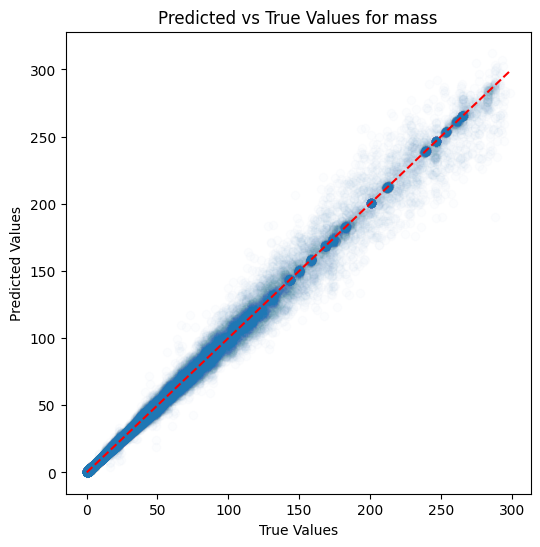

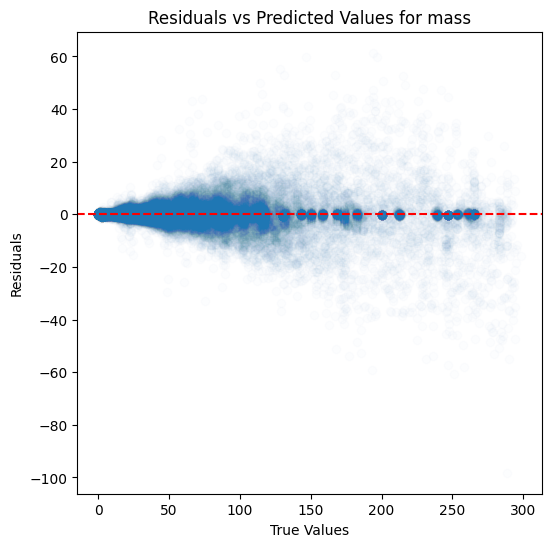

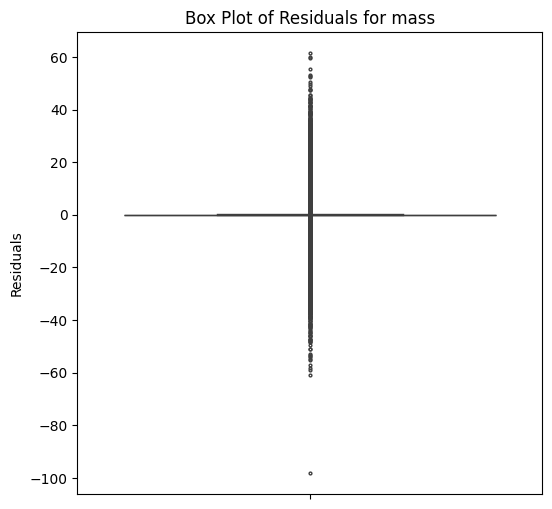

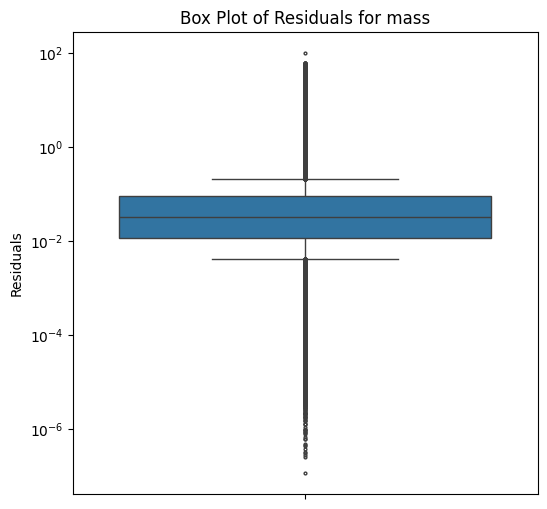

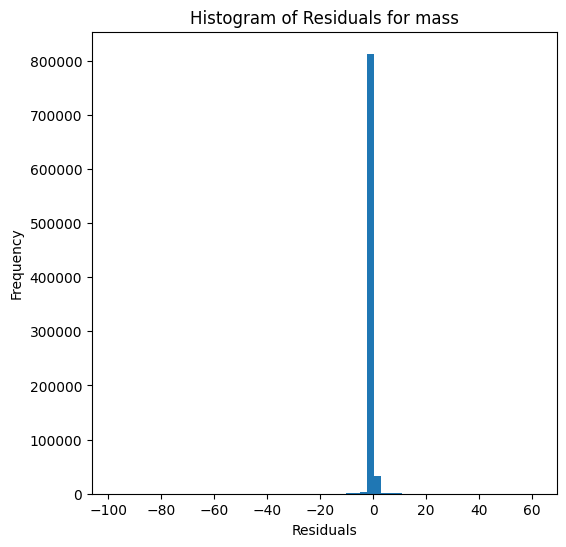

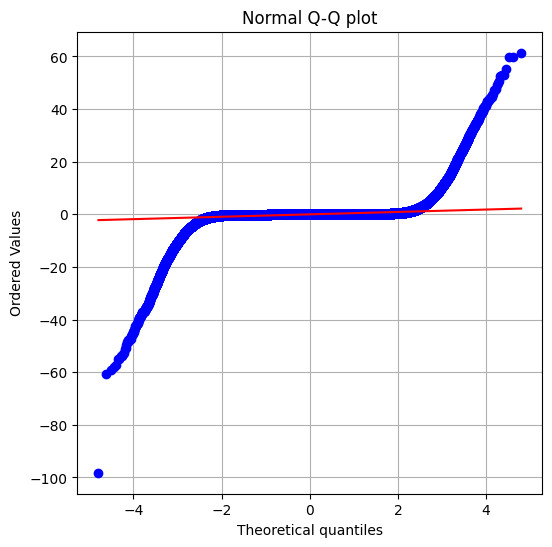

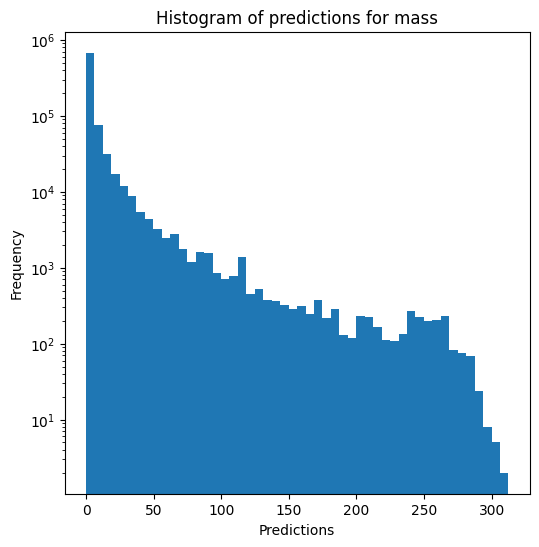

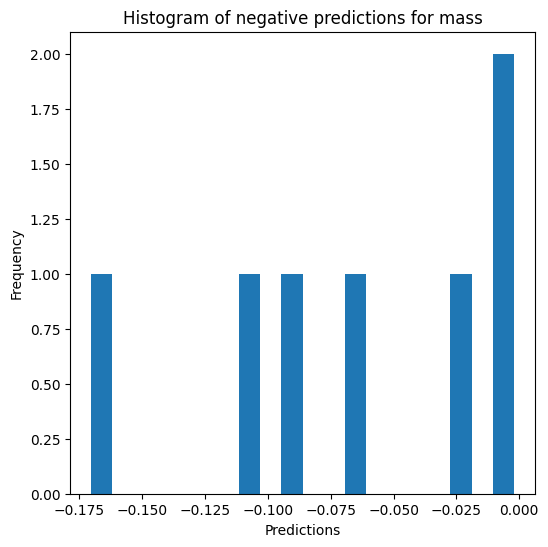


radius results:
RVE :  0.9998793298036383
RMSE :  0.01044114777506761
MAE :  0.006330140390749902
MedAE :  0.004084671235648707
CORR :  0.9999396633545502
MAX_ER :  0.44014824382372864
Percentiles : 
  75th percentile :  0.007696650719609011
  90th percentile :  0.013268710215708768
  95th percentile :  0.01971372347720805
  99th percentile :  0.04175348200022795



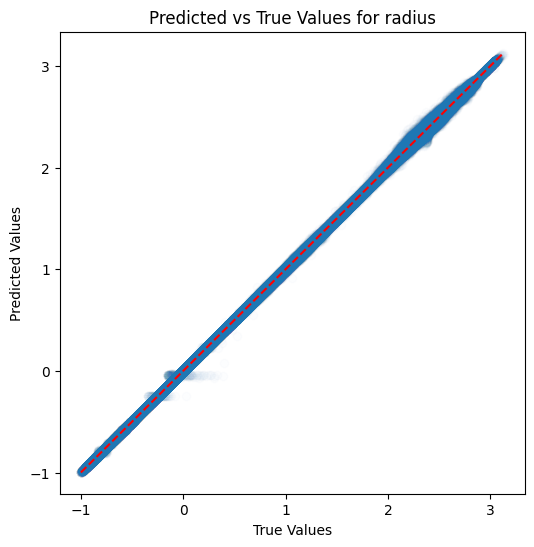

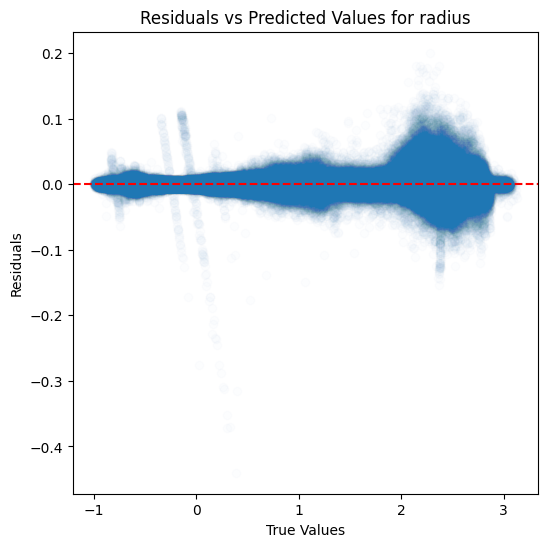

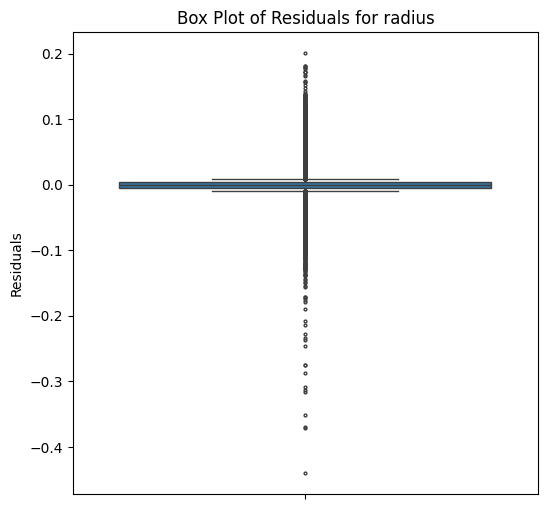

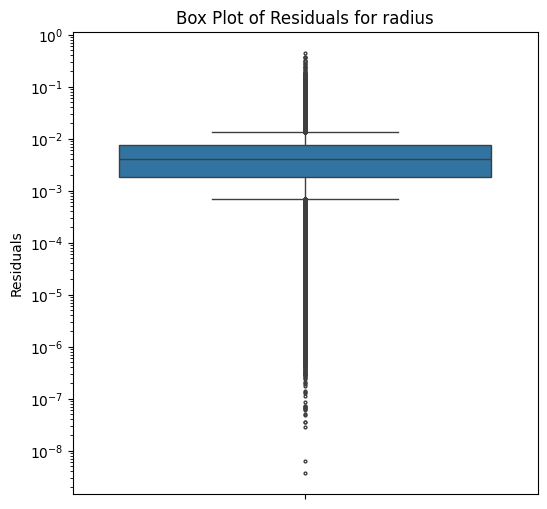

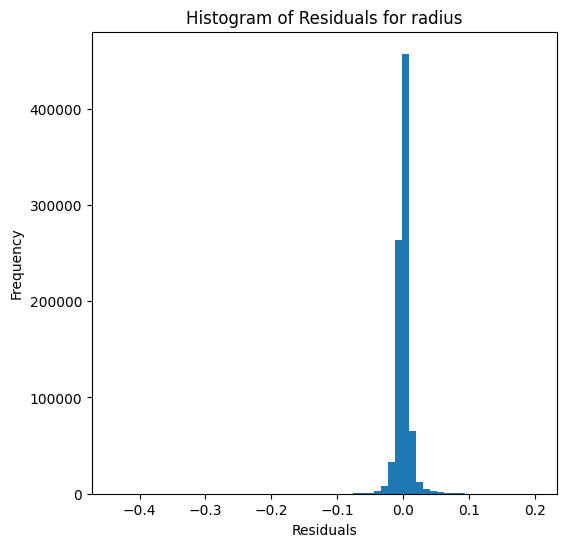

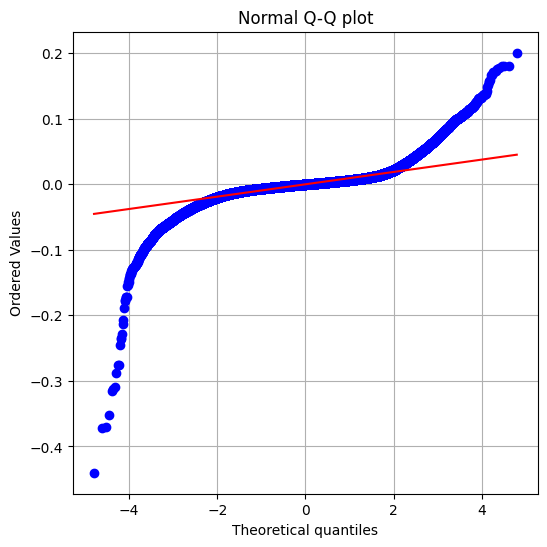

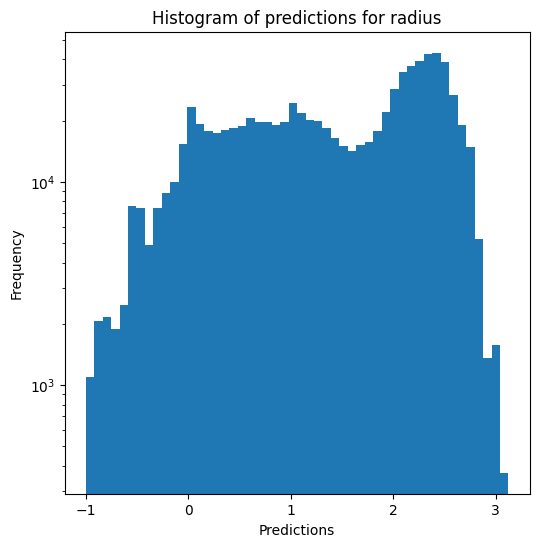

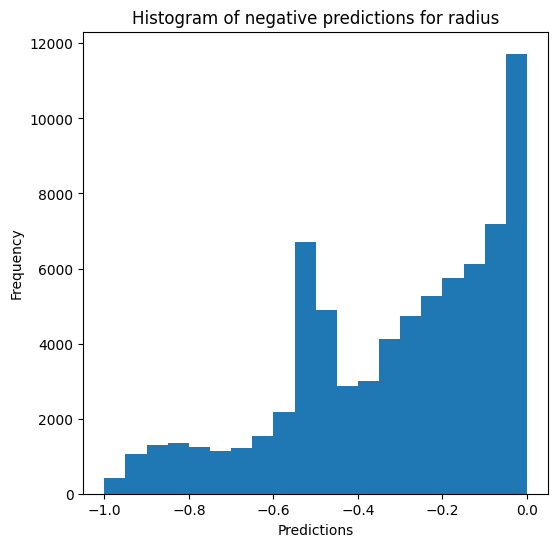

In [8]:
best_params_XGB = {'booster': 'gbtree', 'n_estimators': 600, 'max_depth': 10, 'min_child_weight': 11, 'gamma': 0, 'subsample': 1}

print(path_to_results)
xgb_evaluator = Model_evaluator("XGBoost", path=path_to_results, physical_model=physical_model, output_parameters=["mass", "radius"])
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False, n_jobs=10, **best_params_XGB)

In [11]:
# saving the model to test the topology with a better model than base XGB
import joblib

best_params_XGB = {'booster': 'gbtree', 'n_estimators': 600, 'max_depth': 10, 'min_child_weight': 11, 'gamma': 0, 'subsample': 1}
xgb_mdl = XGBRegressor(**best_params_XGB)
xgb_mdl.fit(X_train, y_train)
joblib.dump(xgb_mdl, '../../../../../../../model/fully_trained/primary_XGB.pkl')

['../../../../../../../model/fully_trained/primary_XGB.pkl']

### Random forest

In [ ]:
# n_estimators, criterion, max_depth, min_samples_split, 

In [ ]:
def RF_objective(trial, X_train, y_train, X_test, y_test):
    # Hyperparameters which will be tuned
    criterion = trial.suggest_categorical("criterion", ["squared_error", "friedman_mse", "poisson", "absolute_error"])
    # n_estimators = trial.suggest_int("n_estimators", 75, 125)
    max_depth = trial.suggest_int("max_depth", 3, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    mdl = RandomForestRegressor(
        criterion = criterion,
        max_depth = max_depth,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        n_jobs = 10
    )
    mdl.fit(X_train, y_train)
    preds = mdl.predict(X_test)
    # truth, preds = Model_trainer.Kfold_pipeline(RandomForestRegressor, X_train_data=X_train, y_train_data=y_train, n_splits=10, 
    #                                             criterion = criterion,
    #                                             # n_estimators = n_estimators,
    #                                             max_depth = max_depth,
    #                                             min_samples_split = min_samples_split,
    #                                             min_samples_leaf = min_samples_leaf,
    #                                             n_jobs = 10
    #                                             )
    metrics_dict = dict()
    for i, output_param in enumerate(output_parameters):
        metrics_dict[output_param] = dict()
        metrics_dict[output_param]["RMSE"] = root_mean_squared_error(y_test[:, i], preds[:, i])
        metrics_dict[output_param]["MAE"] = mean_absolute_error(y_test[:, i], preds[:, i])
        metrics_dict[output_param]["MAX_ER"] = max_error(y_test[:, i], preds[:, i])

    return metrics_dict["mass"]["RMSE"], metrics_dict["mass"]["MAE"], metrics_dict["mass"]["MAX_ER"]

In [ ]:
study_RF = optuna.create_study(directions=["minimize", "minimize", "minimize"]) # we want to minimize the RMSE, MAE and MAX_ER
study_RF.optimize(lambda trial: RF_objective(trial, X_train, y_train, X_test, y_test, output_parameters), n_trials=100)

In [ ]:
for trial in study_RF.best_trials:
    print(f"[RMSE, MAE, MAX_ER] : {trial.values} \n parameters : {trial.params}")

In [ ]:

best_params_RF = 

rf_evaluator = Model_evaluator("radnom_forest", path=path_to_results, physical_model=physical_model, output_parameters=["mass", "radius"])
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False, **best_params_RF, n_jobs=10)